数据文件路径： C:\Users\aaa\CPI-Prediction\data_processed\cpi_monthly.csv
图片保存路径： C:\Users\aaa\CPI-Prediction\results\figures\cpi_series.png
数据读取成功！
数据形状： (316, 3)
前 5 行：


,date,cpi_yoy_growth,cpi_yoy
0,2000-01,0.1,100.1
1,2000-02,0.0,100.0
2,2000-03,-0.1,99.9
3,2000-04,-0.2,99.8
4,2000-05,0.0,100.0


后 5 行：


,date,cpi_yoy_growth,cpi_yoy
311,2025-12,0.8,100.8
312,2026-01,0.2,100.2
313,2026-02,1.3,101.3
314,2026-03,1.0,101.0
315,2026-04,1.2,101.2


列名：
['date', 'cpi_yoy_growth', 'cpi_yoy']

数据类型：
date                  str
cpi_yoy_growth    float64
cpi_yoy           float64
dtype: object

描述性统计：


,cpi_yoy_growth,cpi_yoy
count,316.000000,316.000000
mean,1.902215,101.902215
std,1.919522,1.919522
min,-1.810000,98.190000
25%,0.590000,100.590000
50%,1.700000,101.700000
75%,2.700000,102.700000
max,8.740000,108.740000


最早月份： 2000-01-01 00:00:00
最晚月份： 2026-04-01 00:00:00


,date,cpi_yoy_growth,cpi_yoy
0,2000-01-01,0.1,100.1
1,2000-02-01,0.0,100.0
2,2000-03-01,-0.1,99.9
3,2000-04-01,-0.2,99.8
4,2000-05-01,0.0,100.0


,date,cpi_yoy_growth,cpi_yoy
311,2025-12-01,0.8,100.8
312,2026-01-01,0.2,100.2
313,2026-02-01,1.3,101.3
314,2026-03-01,1.0,101.0
315,2026-04-01,1.2,101.2


各列缺失值数量：
date              0
cpi_yoy_growth    0
cpi_yoy           0
dtype: int64

结论：数据中没有缺失值。
理论月份数量： 316
实际月份数量： 316

结论：月份连续，没有缺失月份。
结论：没有重复月份。


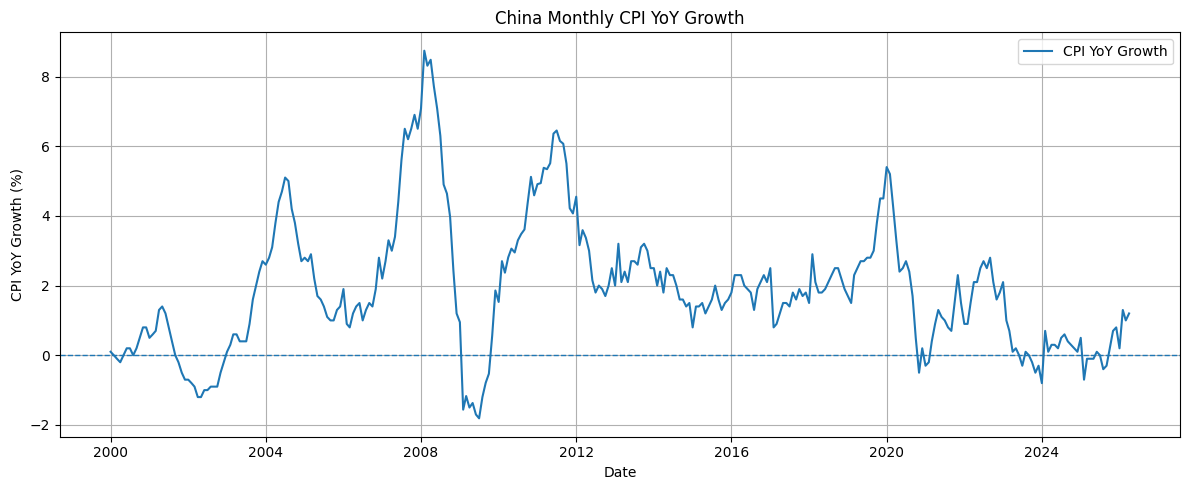

图片已保存到： C:\Users\aaa\CPI-Prediction\results\figures\cpi_series.png


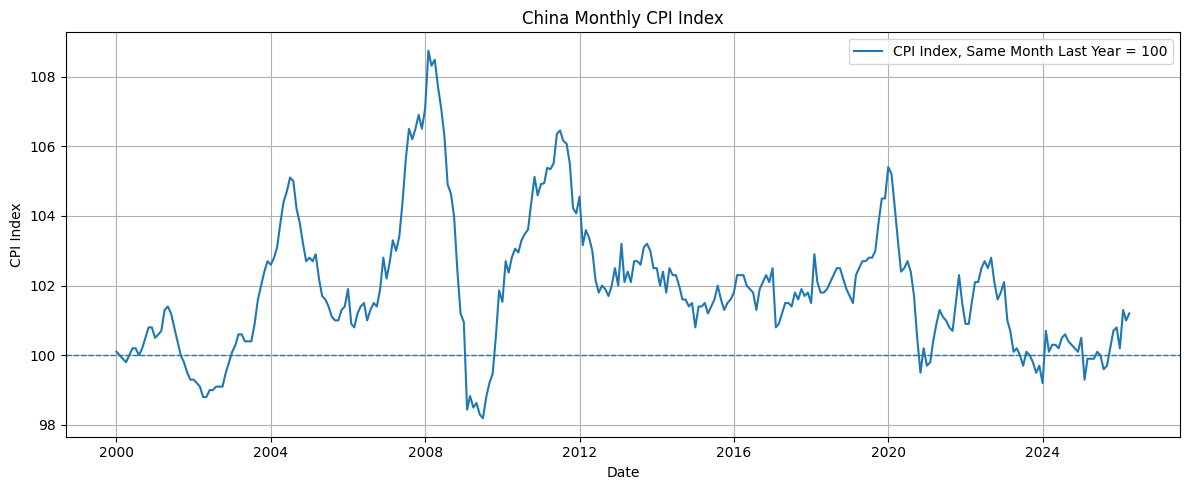

检查后的数据已保存到：
C:\Users\aaa\CPI-Prediction\data_processed\cpi_monthly_checked.csv
CPI 数据检查总结
------------------------------
数据文件： C:\Users\aaa\CPI-Prediction\data_processed\cpi_monthly.csv
样本数量： 316
时间范围： 2000-01 至 2026-04
缺失值总数： 0
缺失月份数量： 0
重复月份数量： 0
CPI 曲线图： C:\Users\aaa\CPI-Prediction\results\figures\cpi_series.png

结论：数据检查通过，可以用于后续滑动窗口构造和基线模型。


In [2]:
#导入库和读取路径
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# 因为 notebook 在 notebooks 文件夹下，
# 这里把项目根目录加入 Python 搜索路径，方便导入 src.config
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_PROCESSED_DIR, FIGURES_DIR


DATA_FILE = DATA_PROCESSED_DIR / "cpi_monthly.csv"
FIGURE_FILE = FIGURES_DIR / "cpi_series.png"

print("数据文件路径：", DATA_FILE)
print("图片保存路径：", FIGURE_FILE)
#读取CPI数据
df = pd.read_csv(DATA_FILE)

print("数据读取成功！")
print("数据形状：", df.shape)

df.head()
#查看前5行和后5行
print("前 5 行：")
display(df.head())

print("后 5 行：")
display(df.tail())
#查看数据基本信息
print("列名：")
print(df.columns.tolist())

print("\n数据类型：")
print(df.dtypes)

print("\n描述性统计：")
display(df.describe())
#统一日期格式并排序
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("最早月份：", df["date"].min())
print("最晚月份：", df["date"].max())

display(df.head())
display(df.tail())
#检查缺失值
missing_values = df.isna().sum()

print("各列缺失值数量：")
print(missing_values)

if missing_values.sum() == 0:
    print("\n结论：数据中没有缺失值。")
else:
    print("\n结论：数据中存在缺失值，缺失行如下：")
    display(df[df.isna().any(axis=1)])
#检查月份是否连续
expected_months = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="MS"
)

actual_months = pd.DatetimeIndex(df["date"])

missing_months = expected_months.difference(actual_months)

print("理论月份数量：", len(expected_months))
print("实际月份数量：", len(actual_months))

if len(missing_months) == 0:
    print("\n结论：月份连续，没有缺失月份。")
else:
    print("\n结论：存在缺失月份：")
    print(missing_months.strftime("%Y-%m").tolist())
#检查是否有重复月份
duplicated_dates = df[df["date"].duplicated(keep=False)]

if duplicated_dates.empty:
    print("结论：没有重复月份。")
else:
    print("结论：存在重复月份：")
    display(duplicated_dates)
#画CPI同比增长率时间序列圈
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["cpi_yoy_growth"],
    linewidth=1.5,
    label="CPI YoY Growth"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Date")
plt.ylabel("CPI YoY Growth (%)")
plt.title("China Monthly CPI YoY Growth")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(FIGURE_FILE, dpi=300)

plt.show()

print("图片已保存到：", FIGURE_FILE)
#画CPI指数时间序列圈
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["cpi_yoy"],
    linewidth=1.5,
    label="CPI Index, Same Month Last Year = 100"
)

plt.axhline(100, linestyle="--", linewidth=1)

plt.xlabel("Date")
plt.ylabel("CPI Index")
plt.title("China Monthly CPI Index")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()
#保存一份检查后的数据
checked_df = df.copy()
checked_df["date"] = checked_df["date"].dt.strftime("%Y-%m")

checked_df.to_csv(
    DATA_PROCESSED_DIR / "cpi_monthly_checked.csv",
    index=False,
    encoding="utf-8-sig"
)

print("检查后的数据已保存到：")
print(DATA_PROCESSED_DIR / "cpi_monthly_checked.csv")
#输出数据检查并总结
print("CPI 数据检查总结")
print("-" * 30)

print("数据文件：", DATA_FILE)
print("样本数量：", len(df))
print("时间范围：", df["date"].min().strftime("%Y-%m"), "至", df["date"].max().strftime("%Y-%m"))
print("缺失值总数：", df.isna().sum().sum())
print("缺失月份数量：", len(missing_months))
print("重复月份数量：", df["date"].duplicated().sum())
print("CPI 曲线图：", FIGURE_FILE)

if df.isna().sum().sum() == 0 and len(missing_months) == 0 and df["date"].duplicated().sum() == 0:
    print("\n结论：数据检查通过，可以用于后续滑动窗口构造和基线模型。")
else:
    print("\n结论：数据仍需进一步检查。")